# NOAA space-weather exploratory analysis

This notebook loads recent NOAA SWPC solar-wind plasma observations and planetary Kp index measurements, visualizes their recent behavior, and summarizes the distributions. All timestamps are normalized to timezone-aware UTC datetimes. Kp values at or above 5 (the geomagnetic-storm threshold used here) are highlighted throughout.

## Setup and data loading

Import the project loaders and the minimal analysis dependencies. The path setup lets the notebook run from the `notebooks/` directory while importing the repository's `src` package.

In [1]:
from pathlib import Path
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_kp_index, load_solar_wind_plasma

# Use explicit plotting defaults rather than a named matplotlib style.
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'font.size': 10,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.color': '#d9d9d9',
    'grid.linewidth': 0.7,
})

plasma = load_solar_wind_plasma()
kp = load_kp_index()

print(f'Solar-wind records: {len(plasma):,}')
print(f'Kp records: {len(kp):,}')
display(plasma.head())
display(kp.head())

Solar-wind records: 2,375
Kp records: 62


,active,source,speed,temperature,density,proton_vx_gse,proton_vy_gse,proton_vz_gse,proton_vx_gsm,proton_vy_gsm,...,alpha_vz_gsm,alpha_sample_size,max_convergence_flag,max_data_flag,max_error_count_flag,max_processing_flag,max_range_flag,max_sample_count_flag,max_telemetry_flag,overall_quality
time_tag,,,,,,,,,,,,,,,,,,,,,
2026-08-02 18:33:00+00:00,True,NaN,413.20,395702,16.70,-405.3,71.1,-38.2,-405.3,61.9,...,NaN,NaN,0,0,0,0,0,0,0,0
2026-08-02 18:33:08+00:00,False,NaN,402.87,239357,21.47,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,0,0,0,0,0,0
2026-08-02 18:34:00+00:00,False,NaN,410.77,163651,2.25,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,0,0,0,0,0,0
2026-08-02 18:34:08+00:00,False,NaN,390.73,224853,22.53,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,0,0,0,0,0,0
2026-08-02 18:35:00+00:00,True,NaN,412.80,369083,15.70,-405.3,67.8,-39.0,-405.3,58.6,...,NaN,NaN,0,0,0,0,0,0,0,0


,Kp,a_running,station_count
time_tag,,,
2026-07-27 00:00:00+00:00,1.67,6,8
2026-07-27 03:00:00+00:00,1.00,4,8
2026-07-27 06:00:00+00:00,2.00,7,8
2026-07-27 09:00:00+00:00,1.33,5,8
2026-07-27 12:00:00+00:00,1.67,6,8


## Prepare UTC-indexed analysis frames

The loaders return UTC-indexed frames. These helpers enforce that contract, select the available solar-wind metrics, treat NOAA's `-9999` fill values as missing observations, and create a consistent color for each Kp severity band.

In [2]:
def ensure_utc_index(frame: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with a sorted, timezone-aware UTC DatetimeIndex."""
    prepared = frame.copy()
    prepared.index = pd.to_datetime(prepared.index, errors='coerce', utc=True)
    prepared = prepared.loc[prepared.index.notna()]
    return prepared[~prepared.index.duplicated(keep='last')].sort_index()


def kp_severity_color(value: float) -> str:
    """Map a Kp value to green (0-3), yellow (4-5), or red (6+)."""
    if pd.isna(value):
        return '#bdbdbd'
    if value >= 6:
        return '#d73027'
    if value >= 4:
        return '#f6c344'
    return '#3a9d5d'


plasma = ensure_utc_index(plasma)
kp = ensure_utc_index(kp)

required_plasma_columns = ['speed', 'density', 'temperature']
missing_plasma_columns = set(required_plasma_columns).difference(plasma.columns)
if missing_plasma_columns:
    raise KeyError(f'Missing expected plasma columns: {sorted(missing_plasma_columns)}')
if 'Kp' not in kp.columns:
    raise KeyError("Expected a 'Kp' column in the NOAA Kp data.")

plasma_metrics = plasma[required_plasma_columns].apply(pd.to_numeric, errors='coerce')
# NOAA uses -9999 as a numeric missing-data sentinel in some plasma records.
plasma_metrics = plasma_metrics.replace(-9999, float('nan'))
kp_values = pd.to_numeric(kp['Kp'], errors='coerce').dropna()
storm_times = kp_values.index[kp_values >= 5]

print(f'UTC coverage — plasma: {plasma.index.min()} to {plasma.index.max()}')
print(f'UTC coverage — Kp: {kp.index.min()} to {kp.index.max()}')
print(f'Kp >= 5 timestamps: {len(storm_times):,}')

UTC coverage — plasma: 2026-08-02 18:33:00+00:00 to 2026-08-03 18:29:00+00:00
UTC coverage — Kp: 2026-07-27 00:00:00+00:00 to 2026-08-03 15:00:00+00:00
Kp >= 5 timestamps: 1


## Individual time series

Plot solar-wind velocity and density separately, then show Kp as a severity-colored bar chart. Vertical dashed lines mark every Kp ≥ 5 timestamp across the solar-wind plots.

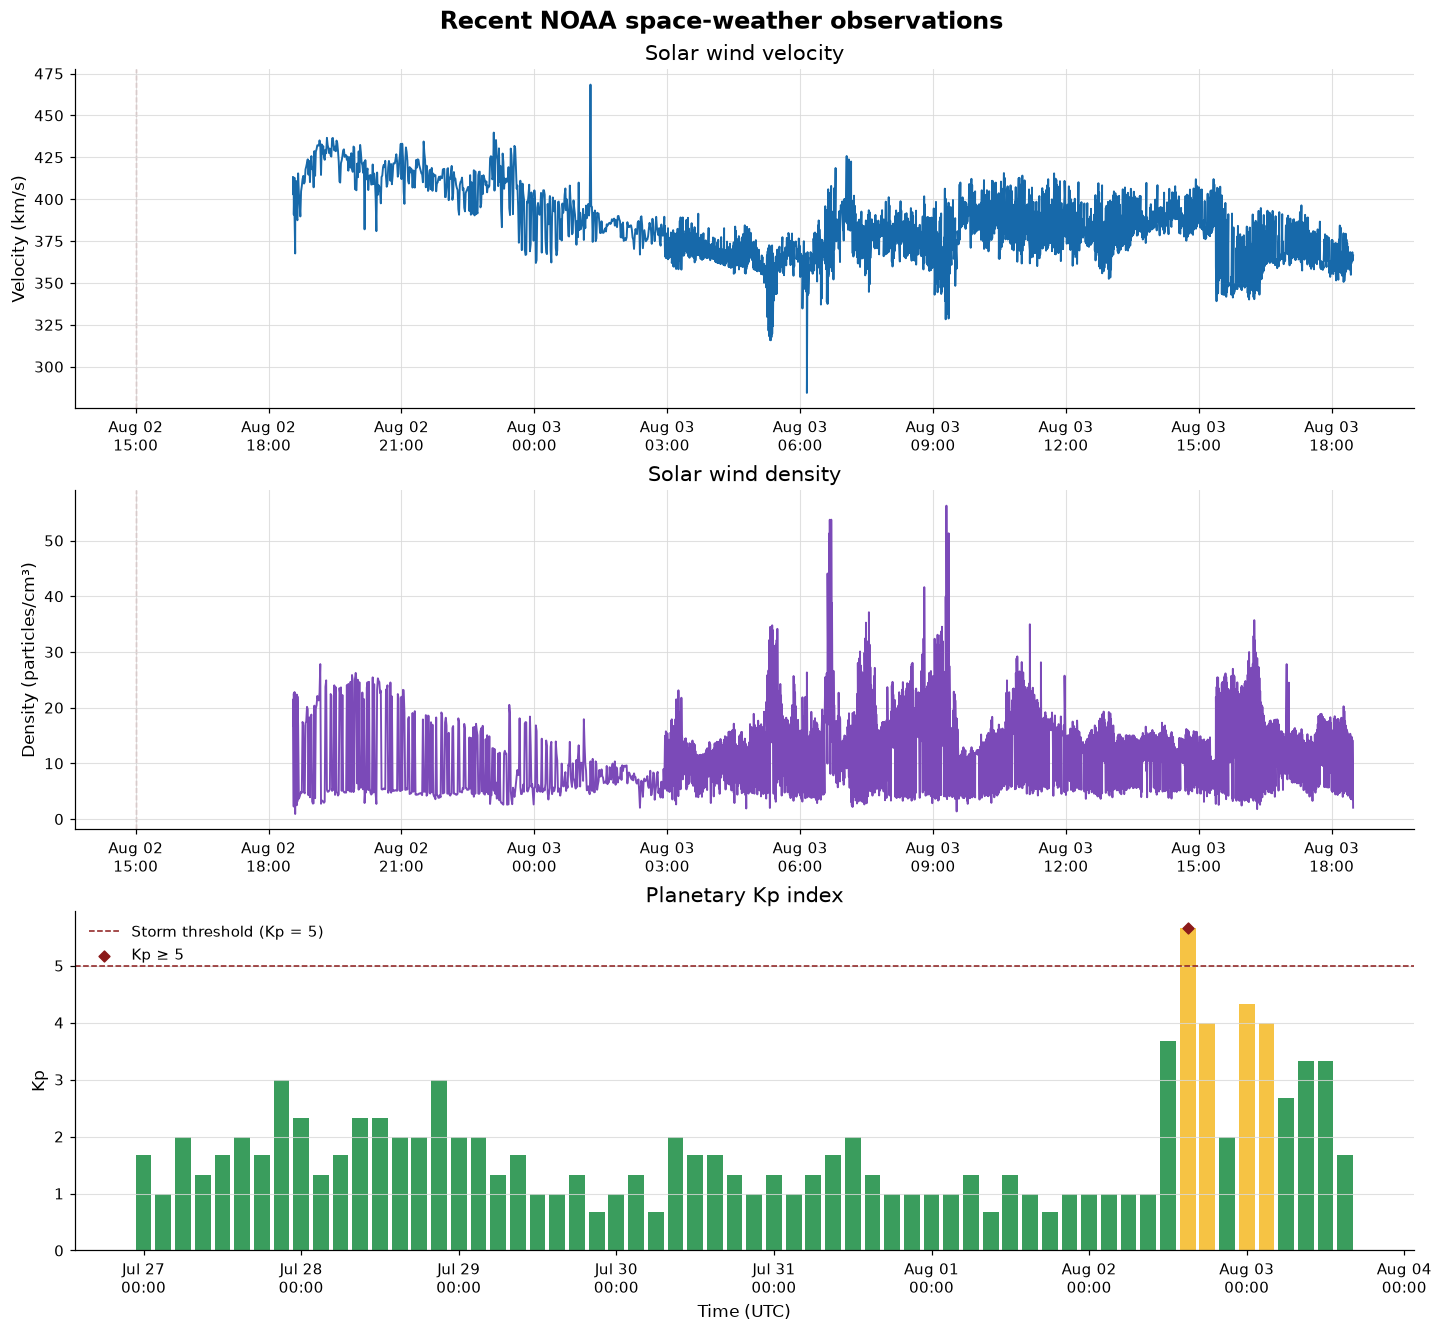

In [3]:
def add_storm_markers(axis: plt.Axes, timestamps: pd.DatetimeIndex) -> None:
    """Add unobtrusive vertical markers for Kp >= 5 timestamps."""
    for timestamp in timestamps:
        axis.axvline(timestamp, color='#8b1a1a', linestyle='--', linewidth=0.9, alpha=0.45, zorder=1)


fig, axes = plt.subplots(3, 1, figsize=(13, 12), constrained_layout=True)

axes[0].plot(plasma_metrics.index, plasma_metrics['speed'], color='#1769aa', linewidth=1.25)
add_storm_markers(axes[0], storm_times)
axes[0].set(title='Solar wind velocity', ylabel='Velocity (km/s)')
axes[0].grid(True, alpha=0.8)

axes[1].plot(plasma_metrics.index, plasma_metrics['density'], color='#7b4ab8', linewidth=1.25)
add_storm_markers(axes[1], storm_times)
axes[1].set(title='Solar wind density', ylabel='Density (particles/cm³)')
axes[1].grid(True, alpha=0.8)

axes[2].bar(kp_values.index, kp_values, width=pd.Timedelta(hours=2.4),
            color=[kp_severity_color(value) for value in kp_values], edgecolor='none')
axes[2].axhline(5, color='#8b1a1a', linestyle='--', linewidth=1, label='Storm threshold (Kp = 5)')
axes[2].scatter(storm_times, kp_values.loc[storm_times], color='#8b1a1a', marker='D', s=25,
                zorder=3, label='Kp ≥ 5')
axes[2].set(title='Planetary Kp index', xlabel='Time (UTC)', ylabel='Kp')
axes[2].set_ylim(bottom=0)
axes[2].grid(True, axis='y', alpha=0.8)
axes[2].legend(frameon=False, loc='upper left')

for axis in axes:
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M', tz='UTC'))

fig.suptitle('Recent NOAA space-weather observations', fontsize=16, fontweight='bold')
plt.show()

## Combined view

This stacked plot aligns velocity, density, and Kp on one shared UTC time axis. Storm markers make it easier to visually inspect solar-wind conditions near elevated geomagnetic activity.

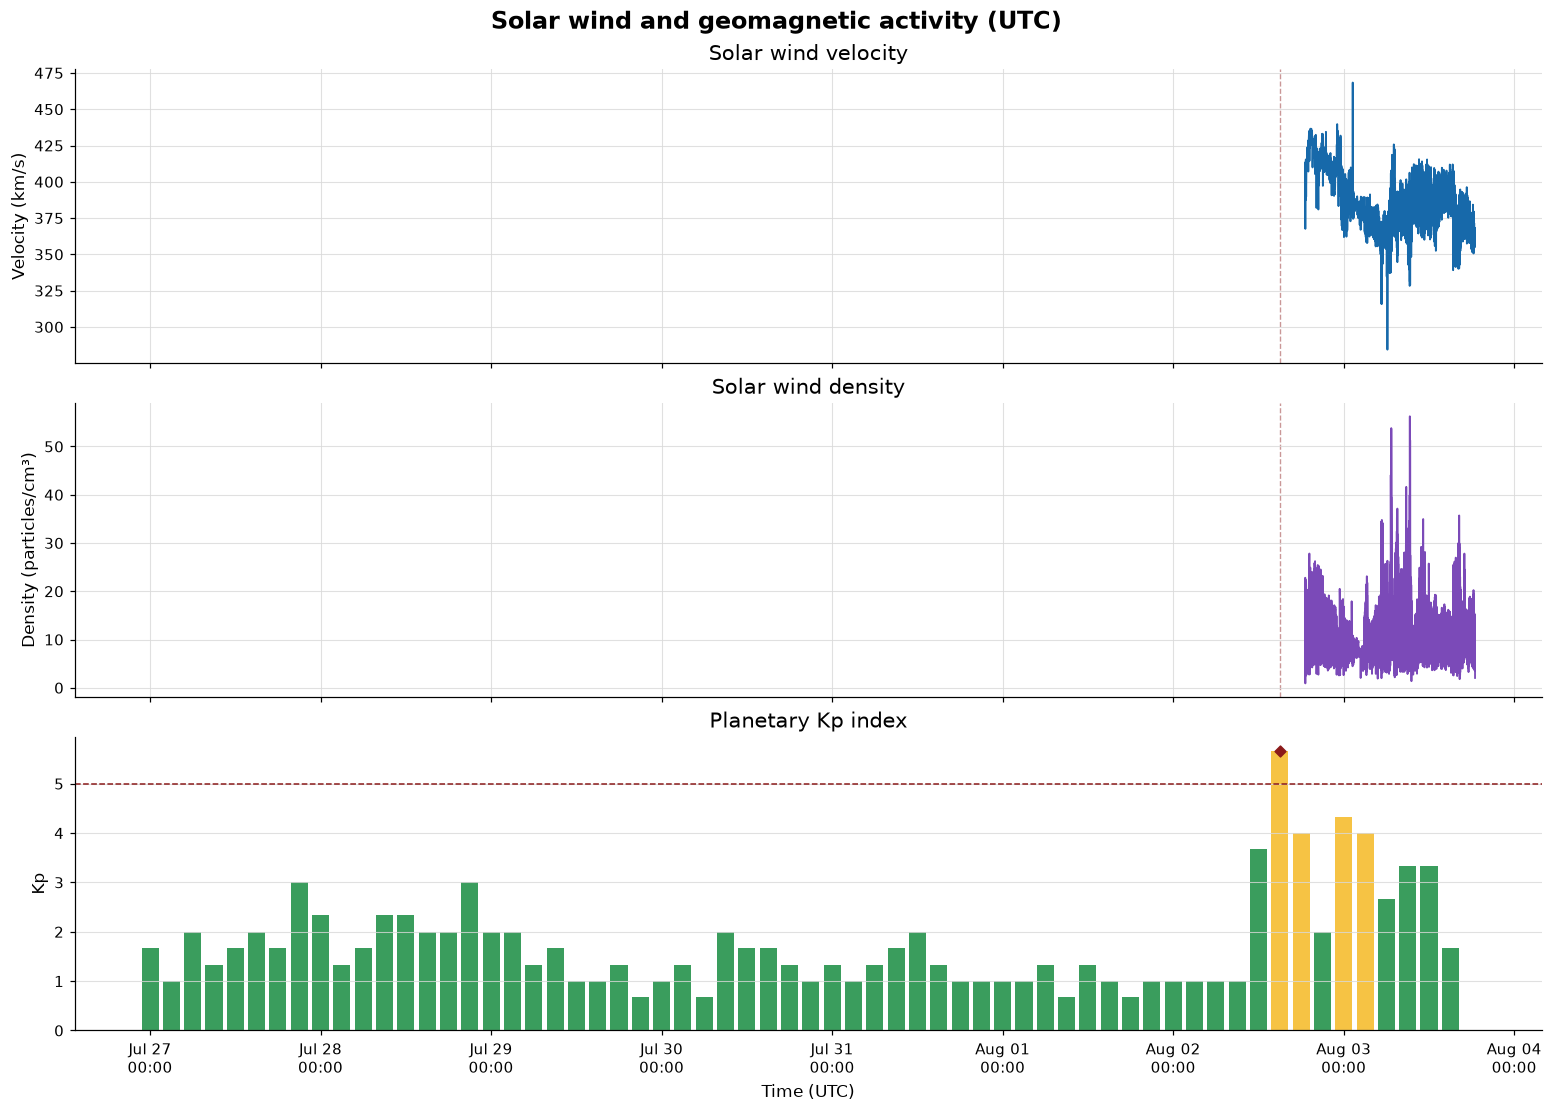

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)

series_config = [
    ('speed', 'Solar wind velocity', 'Velocity (km/s)', '#1769aa'),
    ('density', 'Solar wind density', 'Density (particles/cm³)', '#7b4ab8'),
]
for axis, (column, title, ylabel, color) in zip(axes[:2], series_config):
    axis.plot(plasma_metrics.index, plasma_metrics[column], color=color, linewidth=1.2)
    add_storm_markers(axis, storm_times)
    axis.set(title=title, ylabel=ylabel)
    axis.grid(True, alpha=0.8)

axes[2].bar(kp_values.index, kp_values, width=pd.Timedelta(hours=2.4),
            color=[kp_severity_color(value) for value in kp_values], edgecolor='none')
axes[2].axhline(5, color='#8b1a1a', linestyle='--', linewidth=1, label='Storm threshold (Kp = 5)')
axes[2].scatter(storm_times, kp_values.loc[storm_times], color='#8b1a1a', marker='D', s=25, zorder=3)
axes[2].set(title='Planetary Kp index', ylabel='Kp', xlabel='Time (UTC)')
axes[2].set_ylim(bottom=0)
axes[2].grid(True, axis='y', alpha=0.8)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M', tz='UTC'))
fig.suptitle('Solar wind and geomagnetic activity (UTC)', fontsize=16, fontweight='bold')
plt.show()

## Descriptive statistics and storm timestamps

Calculate count, mean, standard deviation, extrema, and selected percentiles for each metric. The final table lists all loaded timestamps meeting the Kp ≥ 5 geomagnetic-storm threshold.

In [5]:
metrics = pd.concat([
    plasma_metrics.rename(columns={'speed': 'velocity'}),
    kp_values.rename('Kp'),
], axis=1, sort=False)

statistics = metrics.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
statistics = statistics.rename(columns={
    '50%': 'median', '5%': 'p05', '25%': 'p25', '75%': 'p75', '95%': 'p95'
})
display(statistics[['count', 'mean', 'std', 'min', 'p05', 'p25', 'median', 'p75', 'p95', 'max']].round(2))

storm_events = kp_values.loc[kp_values >= 5].to_frame(name='Kp')
storm_events.index.name = 'time_utc'
if storm_events.empty:
    print('No Kp >= 5 timestamps were present in the loaded data.')
else:
    display(storm_events)

,count,mean,std,min,p05,p25,median,p75,p95,max
velocity,2373.0,381.44,20.38,284.35,351.74,366.40,379.60,394.00,418.81,468.38
density,2373.0,12.16,7.43,0.91,3.69,5.31,11.76,16.39,25.23,56.26
temperature,2373.0,177195.75,75759.01,14626.00,61620.40,122692.00,178492.00,221610.00,302979.20,725270.00
Kp,62.0,1.78,1.01,0.67,0.69,1.00,1.50,2.00,3.98,5.67


,Kp
time_utc,
2026-08-02 15:00:00+00:00,5.67
